In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("demographics.csv")

In [3]:
data.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents
0,10000,41,$61800,2.2,Full-time,Graduate,Married,2
1,10001,38,"28,600",7.0,FULL_TIME,High School,Married,0
2,10002,18,"$20,700",0.8,FULL_TIME,Bachelor,Single,0
3,10003,27,"31,400",4.8,Full Time,Bachelor,Single,0
4,10004,26,$24600,5.2,Fulltime,High School,Single,0


In [4]:
data.shape

(89999, 8)

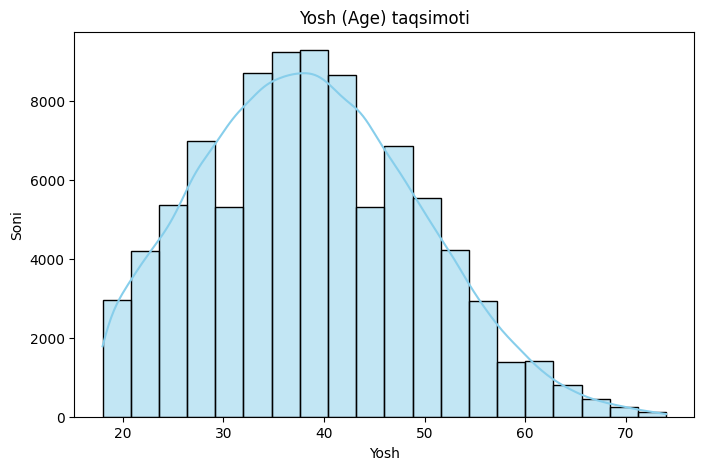

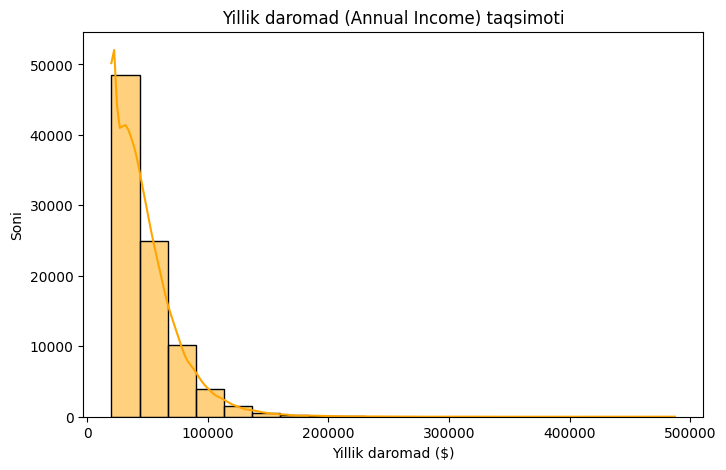

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\2931770574.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='employment_type', palette='viridis')


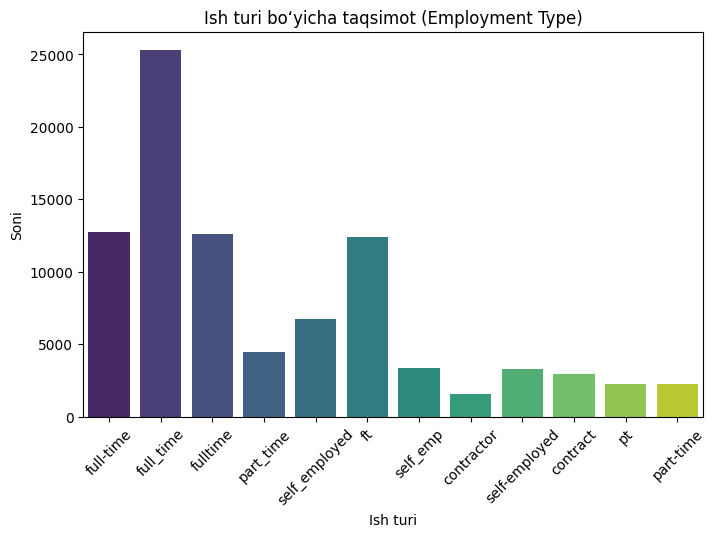

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\2931770574.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='education', palette='coolwarm')


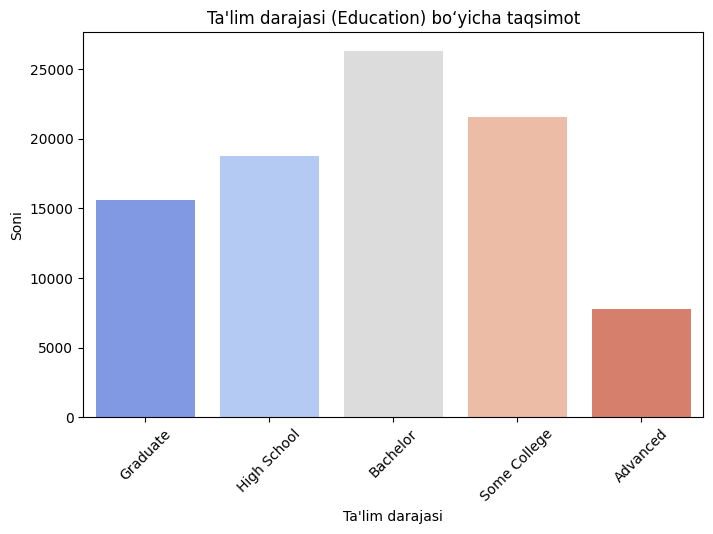

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\2931770574.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='marital_status', palette='magma')


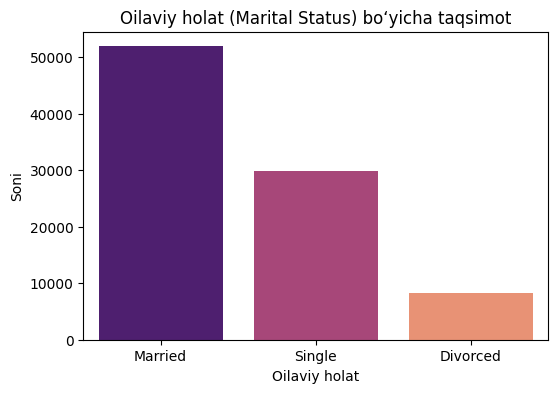

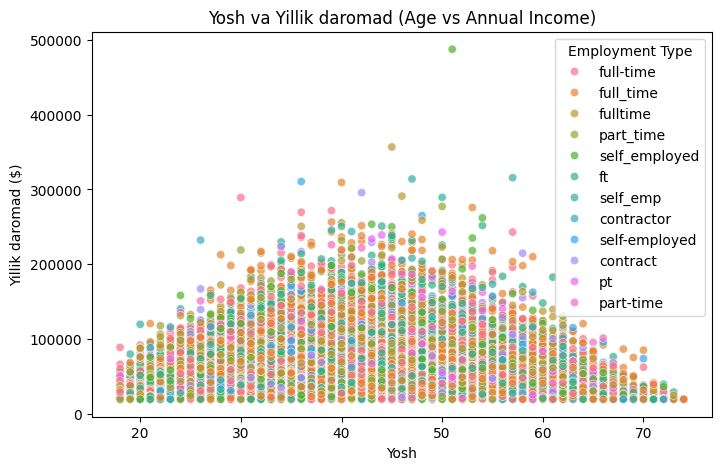

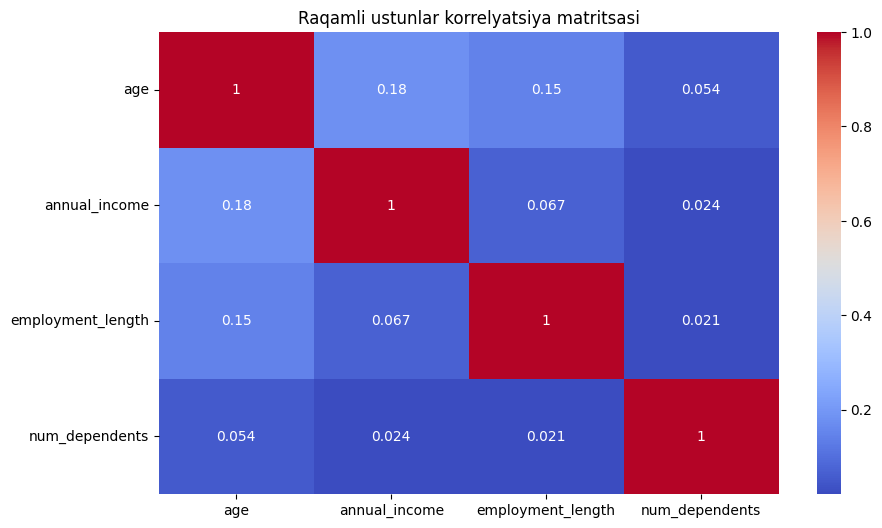


Tozalangan data head:
   cust_id  age  annual_income  employment_length employment_type  \
0    10000   41          61800                2.2       full-time   
1    10001   38          28600                7.0       full_time   
2    10002   18          20700                0.8       full_time   
3    10003   27          31400                4.8       full_time   
4    10004   26          24600                5.2        fulltime   

     education marital_status  num_dependents  
0     Graduate        Married               2  
1  High School        Married               0  
2     Bachelor         Single               0  
3     Bachelor         Single               0  
4  High School         Single               0  


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# 1) Faylni o'qish
# ====================================================
data = pd.read_csv("demographics.csv")

# ====================================================
# 2) Duplicatlarni olib tashlash
# ====================================================
data = data.drop_duplicates()

# ====================================================
# 3) Pul ustunini float ga aylantirish
# ====================================================
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# ====================================================
# 4) Employment type bir hil formatga keltirish
# ====================================================
data['employment_type'] = data['employment_type'].astype(str).str.lower().str.replace(' ','_')

# ====================================================
# 5) Education va marital status bir hil format
# ====================================================
data['education'] = data['education'].astype(str).str.title()
data['marital_status'] = data['marital_status'].astype(str).str.title()

# ====================================================
# 6) NaN qiymatlarni to‘ldirish
# ====================================================
num_cols = ['age','annual_income','employment_length','num_dependents']
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

cat_cols = ['employment_type','education','marital_status']
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ====================================================
# 7) Ustun turlarini to‘g‘irlash
# ====================================================
data['cust_id'] = pd.to_numeric(data['cust_id'], errors='coerce').astype('Int64')
data['num_dependents'] = data['num_dependents'].astype('Int64')

# ====================================================
# 8) Data tahlil va grafiklar
# ====================================================

# 8.1) Age taqsimoti
plt.figure(figsize=(8,5))
sns.histplot(data['age'], bins=20, kde=True, color='skyblue')
plt.title("Yosh (Age) taqsimoti")
plt.xlabel("Yosh")
plt.ylabel("Soni")
plt.show()

# 8.2) Annual income taqsimoti
plt.figure(figsize=(8,5))
sns.histplot(data['annual_income'], bins=20, kde=True, color='orange')
plt.title("Yillik daromad (Annual Income) taqsimoti")
plt.xlabel("Yillik daromad ($)")
plt.ylabel("Soni")
plt.show()

# 8.3) Employment type bo‘yicha taqsimot
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='employment_type', palette='viridis')
plt.title("Ish turi bo‘yicha taqsimot (Employment Type)")
plt.xlabel("Ish turi")
plt.ylabel("Soni")
plt.xticks(rotation=45)
plt.show()

# 8.4) Education bo‘yicha taqsimot
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='education', palette='coolwarm')
plt.title("Ta'lim darajasi (Education) bo‘yicha taqsimot")
plt.xlabel("Ta'lim darajasi")
plt.ylabel("Soni")
plt.xticks(rotation=45)
plt.show()

# 8.5) Marital status bo‘yicha taqsimot
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='marital_status', palette='magma')
plt.title("Oilaviy holat (Marital Status) bo‘yicha taqsimot")
plt.xlabel("Oilaviy holat")
plt.ylabel("Soni")
plt.show()

# 8.6) Age vs Annual Income
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='annual_income', hue='employment_type', alpha=0.7)
plt.title("Yosh va Yillik daromad (Age vs Annual Income)")
plt.xlabel("Yosh")
plt.ylabel("Yillik daromad ($)")
plt.legend(title="Employment Type")
plt.show()

# 8.7) Heatmap: korrelyatsiya
plt.figure(figsize=(10,6))
corr_matrix = data[['age','annual_income','employment_length','num_dependents']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Raqamli ustunlar korrelyatsiya matritsasi")
plt.show()

# ====================================================
# 9) Tozalangan data preview
# ====================================================
print("\nTozalangan data head:")
print(data.head())


In [6]:
data.to_csv("demographics_clean.csv", index=False)
print("Tozalangan data demographics_clean.csv nomi bilan saqlandi.")

Tozalangan data demographics_clean.csv nomi bilan saqlandi.


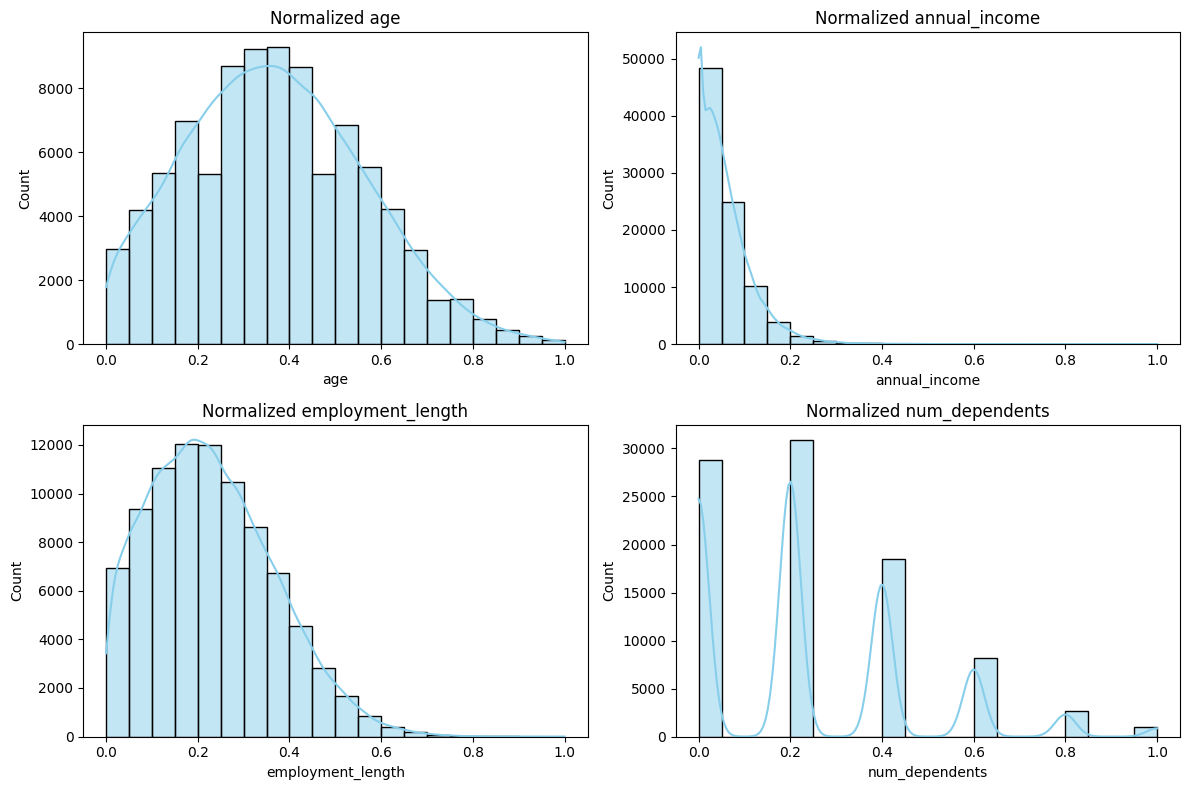

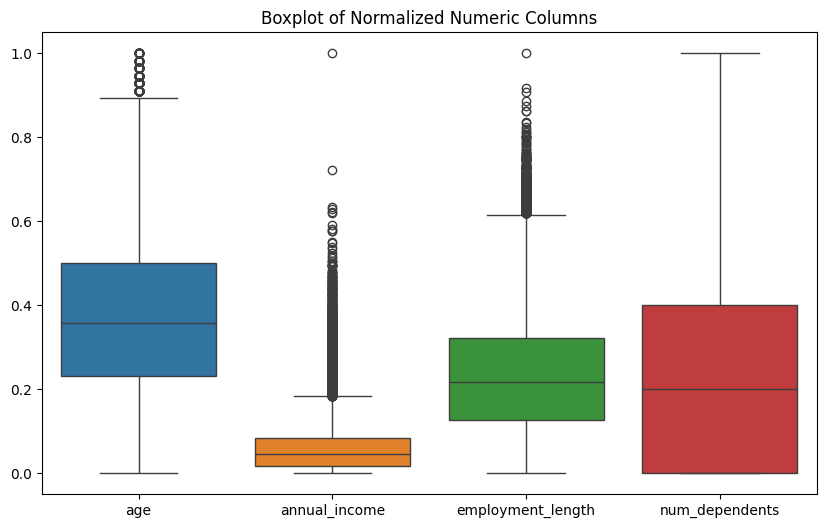

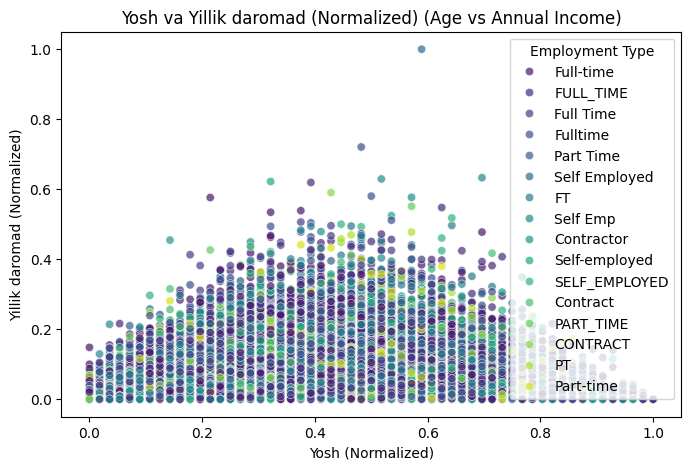

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# CSVni o'qish
data = pd.read_csv("demographics.csv")  # tozalangan data

# Raqamli ustunlar
num_cols = ['age', 'annual_income', 'employment_length', 'num_dependents']

# Pul ustunini floatga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# Normalizatsiya
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# =======================
# 1) Histogramlar
# =======================
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(data[col], bins=20, kde=True, color='skyblue')
    plt.title(f'Normalized {col}')
plt.tight_layout()
plt.show()

# =======================
# 2) Boxplotlar
# =======================
plt.figure(figsize=(10,6))
sns.boxplot(data=data[num_cols])
plt.title('Boxplot of Normalized Numeric Columns')
plt.show()


# Scatter plot: Age vs Annual Income (Normalized)
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='annual_income', hue='employment_type', alpha=0.7, palette='viridis')
plt.title("Yosh va Yillik daromad (Normalized) (Age vs Annual Income)")
plt.xlabel("Yosh (Normalized)")
plt.ylabel("Yillik daromad (Normalized)")
plt.legend(title="Employment Type")
plt.show()


In [8]:
data.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents
0,10000,0.410714,0.089469,0.092050,Full-time,Graduate,Married,0.4
1,10001,0.357143,0.018408,0.292887,FULL_TIME,High School,Married,0.0
2,10002,0.000000,0.001498,0.033473,FULL_TIME,Bachelor,Single,0.0
3,10003,0.160714,0.024401,0.200837,Full Time,Bachelor,Single,0.0
4,10004,0.142857,0.009846,0.217573,Fulltime,High School,Single,0.0


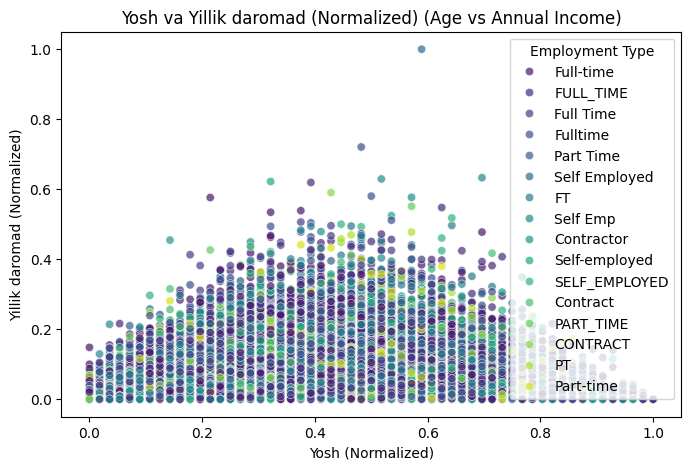

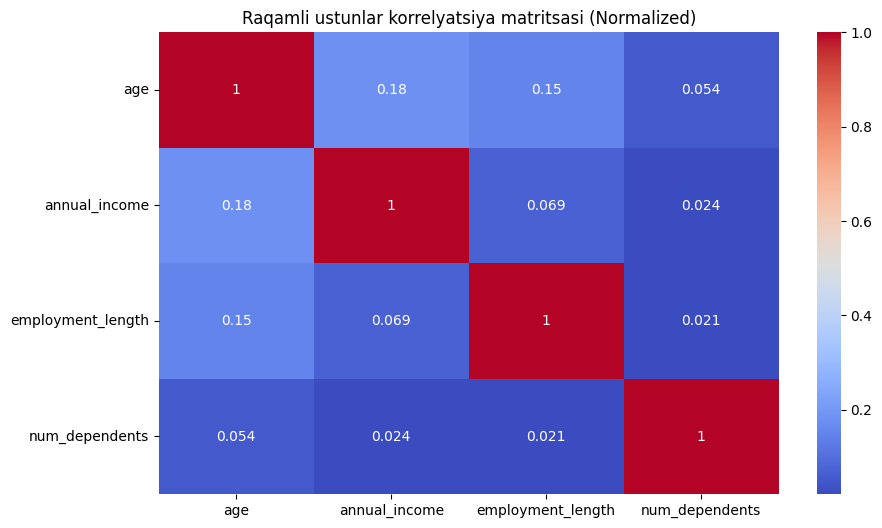


Normalizatsiyalangan data head:
   cust_id       age  annual_income  employment_length employment_type  \
0    10000  0.410714       0.089469           0.092050       Full-time   
1    10001  0.357143       0.018408           0.292887       FULL_TIME   
2    10002  0.000000       0.001498           0.033473       FULL_TIME   
3    10003  0.160714       0.024401           0.200837       Full Time   
4    10004  0.142857       0.009846           0.217573        Fulltime   

     education marital_status  num_dependents  
0     Graduate        Married             0.4  
1  High School        Married             0.0  
2     Bachelor         Single             0.0  
3     Bachelor         Single             0.0  
4  High School         Single             0.0  


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ====================================================
# 1) Tozalangan CSVni o'qish
# ====================================================
data = pd.read_csv("demographics.csv")

# ====================================================
# 2) Raqamli ustunlar
# ====================================================
num_cols = ['age', 'annual_income', 'employment_length', 'num_dependents']

# Pul ustunini floatga aylantirish (agar kerak bo‘lsa)
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# ====================================================
# 3) Normalizatsiya
# ====================================================
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# ====================================================
# 4) Scatter plot: Age vs Annual Income (Normalized)
# ====================================================
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='annual_income', hue='employment_type', alpha=0.7, palette='viridis')
plt.title("Yosh va Yillik daromad (Normalized) (Age vs Annual Income)")
plt.xlabel("Yosh (Normalized)")
plt.ylabel("Yillik daromad (Normalized)")
plt.legend(title="Employment Type")
plt.show()

# ====================================================
# 5) Heatmap: Korrelatsiya (Normalized)
# ====================================================
plt.figure(figsize=(10,6))
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Raqamli ustunlar korrelyatsiya matritsasi (Normalized)")
plt.show()

# ====================================================
# 6) Normalizatsiyalangan data preview
# ====================================================
print("\nNormalizatsiyalangan data head:")
print(data.head())



Eng muhim ustunlar (Top 10):
employment_length            0.324990
age                          0.239289
num_dependents               0.098737
education_High School        0.056743
education_Some College       0.033773
marital_status_Married       0.029747
employment_type_full_time    0.029016
marital_status_Single        0.026339
employment_type_fulltime     0.022055
employment_type_full-time    0.021594
dtype: float64


C:\Users\behru\AppData\Local\Temp\ipykernel_24496\3134118945.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.head(10), y=feat_importances.head(10).index, palette='viridis')


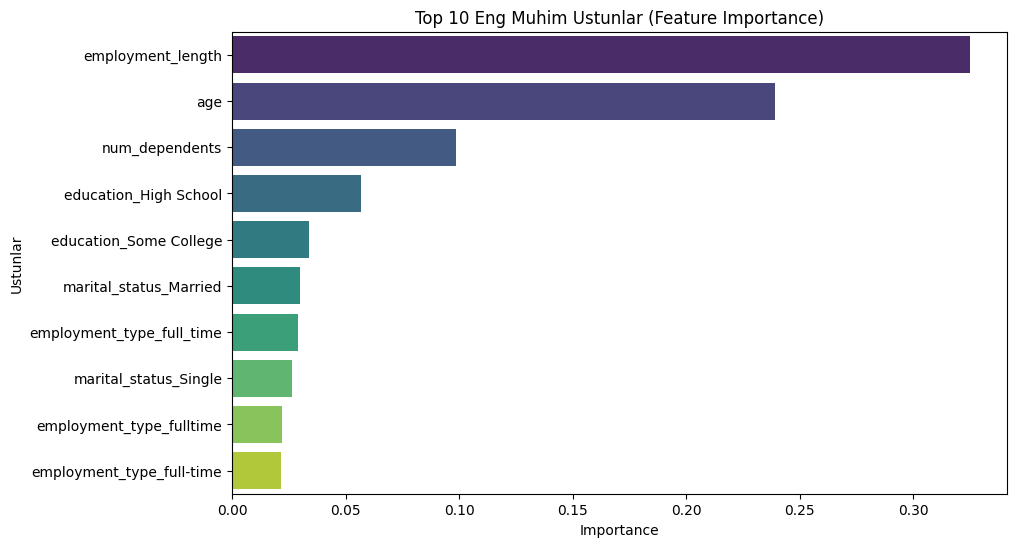

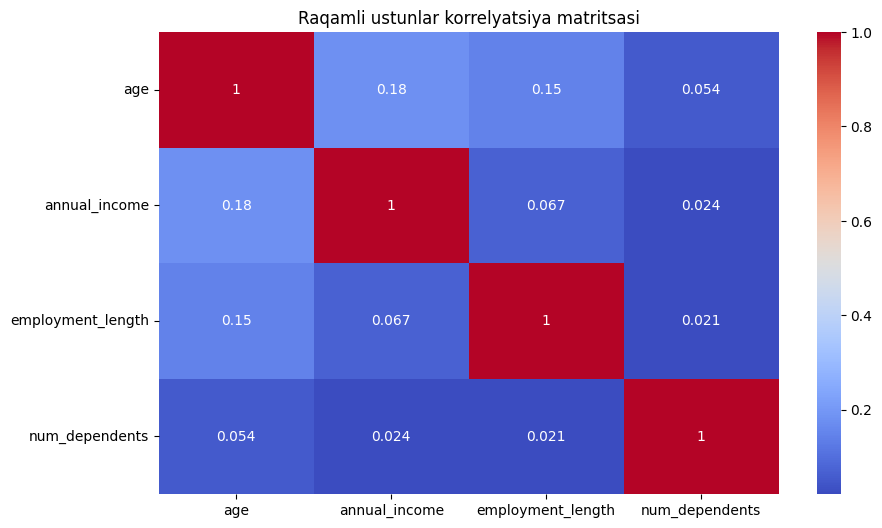

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

# ====================================================
# 1) CSVni o'qish va tozalash
# ====================================================
data = pd.read_csv("demographics.csv")
data = data.drop_duplicates()

# Pul ustunini float ga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# Categorical ustunlarni standartlash
data['employment_type'] = data['employment_type'].astype(str).str.lower().str.replace(' ','_')
data['education'] = data['education'].astype(str).str.title()
data['marital_status'] = data['marital_status'].astype(str).str.title()

# NaN to‘ldirish
num_cols = ['age','annual_income','employment_length','num_dependents']
cat_cols = ['employment_type','education','marital_status']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Raqamli ustunlar tiplari
data['cust_id'] = pd.to_numeric(data['cust_id'], errors='coerce').astype('Int64')
data['num_dependents'] = data['num_dependents'].astype('Int64')

# ====================================================
# 2) Normalizatsiya
# ====================================================
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# ====================================================
# 3) Eng muhim ustunlarni aniqlash (Feature Importance)
# ====================================================
# Annual Income ni target sifatida qabul qilamiz
X = pd.get_dummies(data.drop(['annual_income','cust_id'], axis=1), drop_first=True)
y = data['annual_income']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Feature importance chiqarish
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

print("\nEng muhim ustunlar (Top 10):")
print(feat_importances.head(10))

# ====================================================
# 4) Vizualizatsiya: Top 10 muhim ustun
# ====================================================
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances.head(10), y=feat_importances.head(10).index, palette='viridis')
plt.title("Top 10 Eng Muhim Ustunlar (Feature Importance)")
plt.xlabel("Importance")
plt.ylabel("Ustunlar")
plt.show()

# ====================================================
# 5) Korrelatsiya heatmap
# ====================================================
plt.figure(figsize=(10,6))
sns.heatmap(data[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Raqamli ustunlar korrelyatsiya matritsasi")
plt.show()



✅ Yaxshi ustunlar (foizda):
employment_length         32.498954
age                       23.928924
num_dependents             9.873699
education_High School      5.674335
education_Some College     3.377280
dtype: float64

❌ Yomon ustunlar (foizda):
marital_status_Married           2.974666
employment_type_full_time        2.901623
marital_status_Single            2.633859
employment_type_fulltime         2.205514
employment_type_full-time        2.159370
employment_type_ft               2.157985
education_Bachelor               2.076351
employment_type_self_employed    1.626601
employment_type_part_time        1.215398
employment_type_self_emp         1.166547
employment_type_self-employed    0.986965
employment_type_part-time        0.769441
employment_type_pt               0.763423
employment_type_contractor       0.591466
education_Graduate               0.417599
dtype: float64


C:\Users\behru\AppData\Local\Temp\ipykernel_24496\2304413568.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=good_features, y=good_features.index, palette='Greens_r')


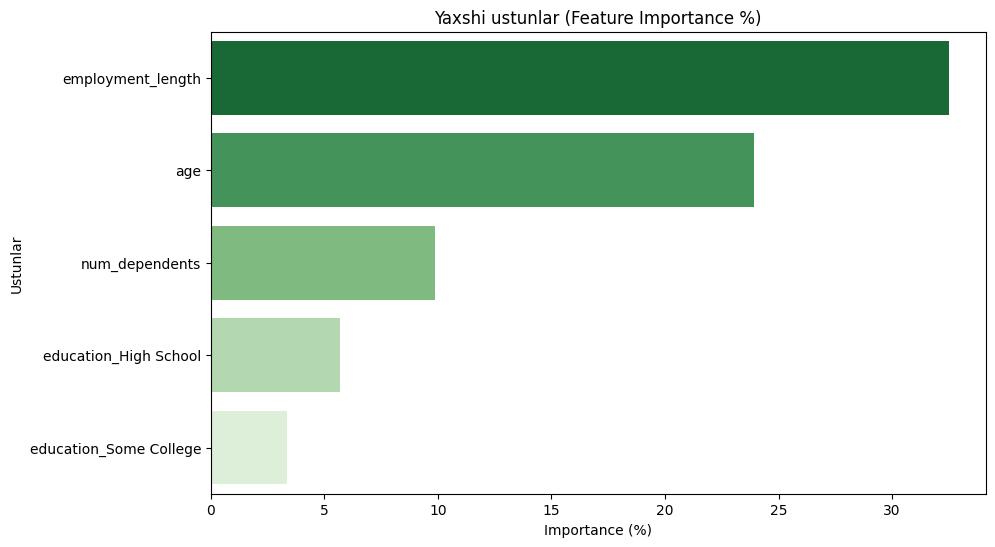

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\2304413568.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bad_features, y=bad_features.index, palette='Reds_r')


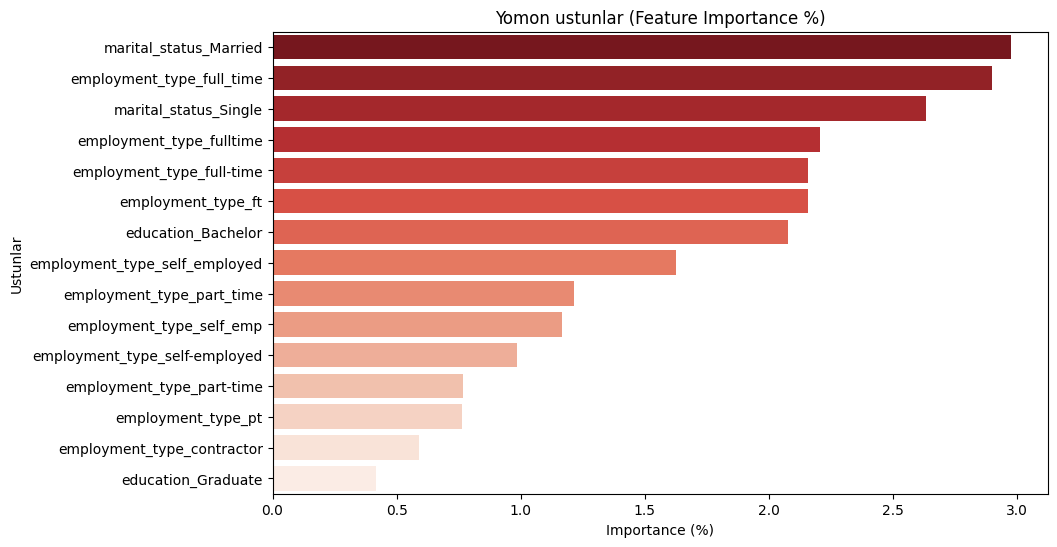

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

# ====================================================
# 1) CSVni o'qish va tozalash
# ====================================================
data = pd.read_csv("demographics.csv")
data = data.drop_duplicates()

# Pul ustunini float ga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# Categorical ustunlarni standartlash
data['employment_type'] = data['employment_type'].astype(str).str.lower().str.replace(' ','_')
data['education'] = data['education'].astype(str).str.title()
data['marital_status'] = data['marital_status'].astype(str).str.title()

# NaN to‘ldirish
num_cols = ['age','annual_income','employment_length','num_dependents']
cat_cols = ['employment_type','education','marital_status']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Raqamli ustunlar tiplari
data['cust_id'] = pd.to_numeric(data['cust_id'], errors='coerce').astype('Int64')
data['num_dependents'] = data['num_dependents'].astype('Int64')

# ====================================================
# 2) Normalizatsiya
# ====================================================
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# ====================================================
# 3) Eng muhim ustunlarni aniqlash
# ====================================================
X = pd.get_dummies(data.drop(['annual_income','cust_id'], axis=1), drop_first=True)
y = data['annual_income']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Feature importance (foiz)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances_percent = 100 * feat_importances / feat_importances.sum()
feat_importances_percent = feat_importances_percent.sort_values(ascending=False)

# ====================================================
# 4) Yaxshi va yomon ustunlarni ajratish
# ====================================================
# Threshold: 3% dan yuqori bo'lgan ustunlar "yaxshi"
good_features = feat_importances_percent[feat_importances_percent > 3]
bad_features = feat_importances_percent[feat_importances_percent <= 3]

print("\n✅ Yaxshi ustunlar (foizda):")
print(good_features)

print("\n❌ Yomon ustunlar (foizda):")
print(bad_features)

# ====================================================
# 5) Vizualizatsiya
# ====================================================
plt.figure(figsize=(10,6))
sns.barplot(x=good_features, y=good_features.index, palette='Greens_r')
plt.title("Yaxshi ustunlar (Feature Importance %)")
plt.xlabel("Importance (%)")
plt.ylabel("Ustunlar")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x=bad_features, y=bad_features.index, palette='Reds_r')
plt.title("Yomon ustunlar (Feature Importance %)")
plt.xlabel("Importance (%)")
plt.ylabel("Ustunlar")
plt.show()


In [12]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

# ==========================
# 1) CSVni o'qish va tozalash
# ==========================
data = pd.read_csv("demographics.csv")
data = data.drop_duplicates()

# Pul ustunini float ga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# Categorical ustunlarni standartlash
data['employment_type'] = data['employment_type'].astype(str).str.lower().str.replace(' ','_')
data['education'] = data['education'].astype(str).str.title()
data['marital_status'] = data['marital_status'].astype(str).str.title()

# NaN to‘ldirish
num_cols = ['age','annual_income','employment_length','num_dependents']
cat_cols = ['employment_type','education','marital_status']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

data['cust_id'] = pd.to_numeric(data['cust_id'], errors='coerce').astype('Int64')
data['num_dependents'] = data['num_dependents'].astype('Int64')

# Normalizatsiya
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# ==========================
# 2) Feature importance
# ==========================
X = pd.get_dummies(data.drop(['annual_income','cust_id'], axis=1), drop_first=True)
y = data['annual_income']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances_percent = 100 * feat_importances / feat_importances.sum()

# ==========================
# 3) Yaxshi va yomon ustunlarni ajratish
# ==========================
threshold = 3  # foiz threshold
good_features = feat_importances_percent[feat_importances_percent > threshold].index
bad_features = feat_importances_percent[feat_importances_percent <= threshold].index

# ==========================
# 4) Har qator uchun hisoblash
# ==========================
row_summary = pd.DataFrame()
row_summary['good_count'] = X[good_features].notnull().sum(axis=1)
row_summary['bad_count'] = X[bad_features].notnull().sum(axis=1)

# ==========================
# 5) Natija
# ==========================
print("Har bir qator bo'yicha yaxshi va yomon ustunlar soni:")
print(row_summary.head())


Har bir qator bo'yicha yaxshi va yomon ustunlar soni:
   good_count  bad_count
0           5         15
1           5         15
2           5         15
3           5         15
4           5         15


In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# ==========================
# 1) CSVni o'qish
# ==========================
data = pd.read_csv("demographics.csv")

# Pul ustunini floatga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# NaN to'ldirish
num_cols = ['age','annual_income','employment_length','num_dependents']
cat_cols = ['employment_type','education','marital_status']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ==========================
# 2) One-hot encoding
# ==========================
X = pd.get_dummies(data.drop(['annual_income','cust_id'], axis=1), drop_first=True)
y = data['annual_income']

# ==========================
# 3) RandomForest bilan feature importance
# ==========================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances_percent = 100 * feat_importances / feat_importances.sum()

# ==========================
# 4) Yaxshi va yomon ustunlarni ajratish
# ==========================
threshold = 3  # % threshold
good_features = feat_importances_percent[feat_importances_percent > threshold].index
bad_features = feat_importances_percent[feat_importances_percent <= threshold].index

# ==========================
# 5) Har bir ustun bo‘yicha DataFrame
# ==========================
column_summary = pd.DataFrame({
    'column': feat_importances_percent.index,
    'importance_percent': feat_importances_percent.round(2),  # <- shu yerda .round(2)
    'status': ['Yaxshi' if col in good_features else 'Yomon' for col in feat_importances_percent.index]
})

print(column_summary)


                                                      column  \
age                                                      age   
employment_length                          employment_length   
num_dependents                                num_dependents   
employment_type_Contract            employment_type_Contract   
employment_type_Contractor        employment_type_Contractor   
employment_type_FT                        employment_type_FT   
employment_type_FULL_TIME          employment_type_FULL_TIME   
employment_type_Full Time          employment_type_Full Time   
employment_type_Full-time          employment_type_Full-time   
employment_type_Fulltime            employment_type_Fulltime   
employment_type_PART_TIME          employment_type_PART_TIME   
employment_type_PT                        employment_type_PT   
employment_type_Part Time          employment_type_Part Time   
employment_type_Part-time          employment_type_Part-time   
employment_type_SELF_EMPLOYED  employmen

In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# ==========================
# 1) CSVni o'qish
# ==========================
data = pd.read_csv("demographics.csv")

# Pul ustunini floatga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# NaN to'ldirish
num_cols = ['age','annual_income','employment_length','num_dependents']
cat_cols = ['employment_type','education','marital_status']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ==========================
# 2) One-hot encoding
# ==========================
X = pd.get_dummies(data.drop(['annual_income','cust_id'], axis=1), drop_first=True)
y = data['annual_income']

# ==========================
# 3) RandomForest bilan feature importance
# ==========================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances_percent = 100 * feat_importances / feat_importances.sum()

# ==========================
# 4) Threshold bilan ajratish
# ==========================
threshold = 3  # % dan yuqori bo'lsa "yaxshi"
good_features = feat_importances_percent[feat_importances_percent > threshold].index
bad_features = feat_importances_percent[feat_importances_percent <= threshold].index

# ==========================
# 5) Har bir ustun bo‘yicha yaxshi/yomon sonini chiqarish
# ==========================
result = []

for col in X.columns:
    if col in good_features:
        good_count = X[col].notnull().sum()
        bad_count = X[col].isnull().sum()
    else:
        good_count = 0
        bad_count = X[col].notnull().sum()
    result.append({
        'column': col,
        'good_count': good_count,
        'bad_count': bad_count
    })

column_counts = pd.DataFrame(result)
print(column_counts)


                           column  good_count  bad_count
0                             age       89999          0
1               employment_length       89999          0
2                  num_dependents       89999          0
3        employment_type_Contract           0      89999
4      employment_type_Contractor           0      89999
5              employment_type_FT           0      89999
6       employment_type_FULL_TIME           0      89999
7       employment_type_Full Time           0      89999
8       employment_type_Full-time           0      89999
9        employment_type_Fulltime           0      89999
10      employment_type_PART_TIME           0      89999
11             employment_type_PT           0      89999
12      employment_type_Part Time           0      89999
13      employment_type_Part-time           0      89999
14  employment_type_SELF_EMPLOYED           0      89999
15       employment_type_Self Emp           0      89999
16  employment_type_Self Employ

In [15]:
import pandas as pd
import numpy as np

# Ma'lumotlarni yuklash
data = pd.read_csv("demographics.csv")

def mad_based_outlier(series, threshold=3.5):
    """
    Modified Z-score orqali outlierlarni aniqlash
    """
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return [], median, mad  # MAD 0 bo'lsa hisoblash mumkin emas
    modified_z_scores = 0.6745 * (series - median) / mad
    outliers = series[np.abs(modified_z_scores) > threshold]
    return outliers, median, mad

# Har bir ustunni tekshirish
for col in data.select_dtypes(include=[np.number]).columns:
    outliers, median, mad = mad_based_outlier(data[col])
    print(f"Column: {col}")
    print(f" - Median: {median}, MAD: {mad}")
    print(f" - Outliers count: {len(outliers)}")
    if len(outliers) > 0:
        print(f" - Outlier values (sample up to 10): {outliers.values[:10]}")
    else:
        print(f" - No outliers detected.\n")

# Agar kategorik ustunlar bo'lsa, ular uchun MAD hisoblash imkonsiz, shuning uchun izoh berish mumkin
for col in data.select_dtypes(exclude=[np.number]).columns:
    print(f"Column: {col} → MAD is not applicable for categorical data.")


Column: cust_id
 - Median: 54999.0, MAD: 22500.0
 - Outliers count: 0
 - No outliers detected.

Column: age
 - Median: 38.0, MAD: 8.0
 - Outliers count: 0
 - No outliers detected.

Column: employment_length
 - Median: 5.2, MAD: nan
 - Outliers count: 0
 - No outliers detected.

Column: num_dependents
 - Median: 1.0, MAD: 1.0
 - Outliers count: 0
 - No outliers detected.

Column: annual_income → MAD is not applicable for categorical data.
Column: employment_type → MAD is not applicable for categorical data.
Column: education → MAD is not applicable for categorical data.
Column: marital_status → MAD is not applicable for categorical data.


In [16]:
data.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents
0,10000,41,$61800,2.2,Full-time,Graduate,Married,2
1,10001,38,"28,600",7.0,FULL_TIME,High School,Married,0
2,10002,18,"$20,700",0.8,FULL_TIME,Bachelor,Single,0
3,10003,27,"31,400",4.8,Full Time,Bachelor,Single,0
4,10004,26,$24600,5.2,Fulltime,High School,Single,0


In [17]:
import pandas as pd
import numpy as np

# Data yuklash
data = pd.read_csv("demographics.csv")

# 1. annual_income ni raqamga aylantirish
data['annual_income'] = data['annual_income'].astype(str).str.replace('[\$,]', '', regex=True)
data['annual_income'] = pd.to_numeric(data['annual_income'], errors='coerce')

# 2. employment_type ni standartlashtirish
data['employment_type'] = data['employment_type'].str.lower().str.replace('_', ' ').str.strip()
data['employment_type'] = data['employment_type'].replace({
    'full time': 'Full-time'
})

# 3. education va marital_status ni bir xil formatga keltirish
data['education'] = data['education'].str.title().str.strip()
data['marital_status'] = data['marital_status'].str.title().str.strip()

# 4. NaN qiymatlarni to‘ldirish
data['age'] = data['age'].fillna(data['age'].median())
data['annual_income'] = data['annual_income'].fillna(data['annual_income'].median())
data['employment_length'] = data['employment_length'].fillna(data['employment_length'].median())
data['num_dependents'] = data['num_dependents'].fillna(0)
data['employment_type'] = data['employment_type'].fillna('Unknown')
data['education'] = data['education'].fillna('Unknown')
data['marital_status'] = data['marital_status'].fillna('Unknown')

# 5. Indexni tiklash
data.reset_index(drop=True, inplace=True)

# Tozalangan data preview
print(data.head())

# Toza data CSV ga saqlash
data.to_csv("demographics_clean.csv", index=False)


<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
C:\Users\behru\AppData\Local\Temp\ipykernel_24496\1876767690.py:8: SyntaxWarning: invalid escape sequence '\$'
  data['annual_income'] = data['annual_income'].astype(str).str.replace('[\$,]', '', regex=True)


   cust_id  age  annual_income  employment_length employment_type  \
0    10000   41          61800                2.2       full-time   
1    10001   38          28600                7.0       Full-time   
2    10002   18          20700                0.8       Full-time   
3    10003   27          31400                4.8       Full-time   
4    10004   26          24600                5.2        fulltime   

     education marital_status  num_dependents  
0     Graduate        Married               2  
1  High School        Married               0  
2     Bachelor         Single               0  
3     Bachelor         Single               0  
4  High School         Single               0  


In [18]:
import pandas as pd
import numpy as np

# Data yuklash
data = pd.read_csv("demographics_clean.csv")  # oldin tozalangan faylni ishlatamiz

def mad_based_outlier(series, threshold=3.5):
    """
    Modified Z-score orqali outlierlarni aniqlash
    """
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return [], median, mad  # MAD 0 bo'lsa hisoblash mumkin emas
    modified_z_scores = 0.6745 * (series - median) / mad
    outliers = series[np.abs(modified_z_scores) > threshold]
    return outliers, median, mad

# Har bir ustunni tekshirish va hisobot
for col in data.columns:
    if np.issubdtype(data[col].dtype, np.number):  # raqamli ustunlar
        outliers, median, mad = mad_based_outlier(data[col])
        print(f"Column: {col}")
        print(f" - Median: {median}, MAD: {mad}")
        print(f" - Outliers count: {len(outliers)}")
        if len(outliers) > 0:
            print(f" - Outlier values (sample up to 10): {outliers.values[:10]}\n")
        else:
            print(f" - No outliers detected.\n")
    else:  # kategorik ustunlar uchun
        print(f"Column: {col} → MAD is 0, cannot compute Modified Z-score reliably.\n")


Column: cust_id
 - Median: 54999.0, MAD: 22500.0
 - Outliers count: 0
 - No outliers detected.

Column: age
 - Median: 38.0, MAD: 8.0
 - Outliers count: 0
 - No outliers detected.

Column: annual_income
 - Median: 41100.0, MAD: 14900.0
 - Outliers count: 2012
 - Outlier values (sample up to 10): [132200 140100 139400 169100 119800 124600 162700 165400 149100 138300]

Column: employment_length
 - Median: 5.2, MAD: 2.3
 - Outliers count: 79
 - Outlier values (sample up to 10): [18.2 19.3 17.3 18.4 20.  17.4 18.6 21.9 17.7 17.4]

Column: employment_type → MAD is 0, cannot compute Modified Z-score reliably.

Column: education → MAD is 0, cannot compute Modified Z-score reliably.

Column: marital_status → MAD is 0, cannot compute Modified Z-score reliably.

Column: num_dependents
 - Median: 1.0, MAD: 1.0
 - Outliers count: 0
 - No outliers detected.



In [19]:
import pandas as pd

# Oldin tozalangan data
data = pd.read_csv("demographics_clean.csv")

# IQR asosida outlier aniqlash funksiyasi (siz yozgan)
def detect_outliers(df, cols):
    """
    Detects outliers in a list of numeric columns using IQR method.
    
    Parameters:
        df (pd.DataFrame): DataFrame to analyze
        cols (list): List of numeric columns to check
        
    Prints outlier summary for each column.
    """
    for col in cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in DataFrame. Skipping...")
            continue
        
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"Column '{col}' is not numeric. Skipping...")
            continue
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        print(f"\nColumn: {col}")
        print(f" - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
        print(f" - Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        print(f" - Outliers count: {len(outliers)}")
        if len(outliers) > 0:
            print(f" - Outlier values (sample up to 10): {outliers.unique()[:10]}")
        else:
            print(" - No outliers detected.")

# Raqamli ustunlarni tanlash
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

# Outlierlarni aniqlash
detect_outliers(data, numeric_cols)



Column: cust_id
 - Q1: 32499.5, Q3: 77498.5, IQR: 44999.0
 - Lower Bound: -34999.0, Upper Bound: 144997.0
 - Outliers count: 0
 - No outliers detected.

Column: age
 - Q1: 31.0, Q3: 46.0, IQR: 15.0
 - Lower Bound: 8.5, Upper Bound: 68.5
 - Outliers count: 373
 - Outlier values (sample up to 10): [69 70 73 74 71 72]

Column: annual_income
 - Q1: 28100.0, Q3: 59300.0, IQR: 31200.0
 - Lower Bound: -18700.0, Upper Bound: 106100.0
 - Outliers count: 3332
 - Outlier values (sample up to 10): [113100 132200 115600 140100 139400 169100 108100 115100 115900 119800]

Column: employment_length
 - Q1: 3.0, Q3: 7.6, IQR: 4.6
 - Lower Bound: -3.8999999999999995, Upper Bound: 14.5
 - Outliers count: 627
 - Outlier values (sample up to 10): [15.  14.6 15.8 16.2 16.8 15.3 15.2 15.6 15.5 16.6]

Column: num_dependents
 - Q1: 0.0, Q3: 2.0, IQR: 2.0
 - Lower Bound: -3.0, Upper Bound: 5.0
 - Outliers count: 0
 - No outliers detected.


In [20]:
data.age.max()

np.int64(74)

In [21]:
import pandas as pd

# Ma'lumotlarni yuklash
data = pd.read_csv("demographics_clean.csv")

# Raqamli ustunlarni tanlash, 'age' ni chiqarib tashlash
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'age']

# Clipping method: past va yuqori chegaralarni percentile orqali aniqlash
for col in numeric_cols:
    lower = data[col].quantile(0.01)  # 1%-percentile
    upper = data[col].quantile(0.99)  # 99%-percentile
    data[col] = data[col].clip(lower, upper)

# Natijani ko‘rish
print(data.head())

# Clipped data ni saqlash
data.to_csv("demographics_clipped_except_age.csv", index=False)


    cust_id  age  annual_income  employment_length employment_type  \
0  10899.98   41          61800                2.2       full-time   
1  10899.98   38          28600                7.0       Full-time   
2  10899.98   18          20700                0.8       Full-time   
3  10899.98   27          31400                4.8       Full-time   
4  10899.98   26          24600                5.2        fulltime   

     education marital_status  num_dependents  
0     Graduate        Married               2  
1  High School        Married               0  
2     Bachelor         Single               0  
3     Bachelor         Single               0  
4  High School         Single               0  


C:\Users\behru\AppData\Local\Temp\ipykernel_24496\284007268.py:13: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].clip(lower, upper)


In [22]:
w = pd.read_csv('demographics_clipped_except_age.csv')

In [23]:
w.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents
0,10899.98,41,61800,2.2,full-time,Graduate,Married,2
1,10899.98,38,28600,7.0,Full-time,High School,Married,0
2,10899.98,18,20700,0.8,Full-time,Bachelor,Single,0
3,10899.98,27,31400,4.8,Full-time,Bachelor,Single,0
4,10899.98,26,24600,5.2,fulltime,High School,Single,0


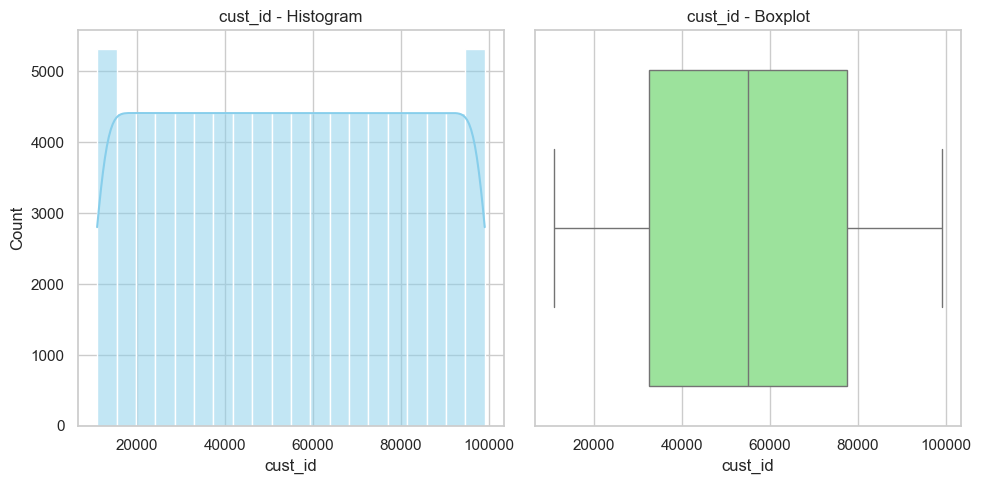

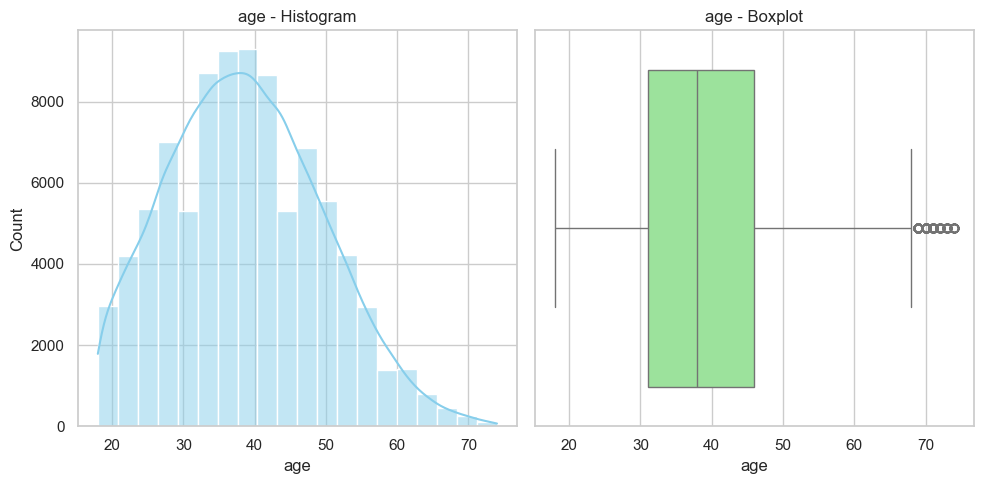

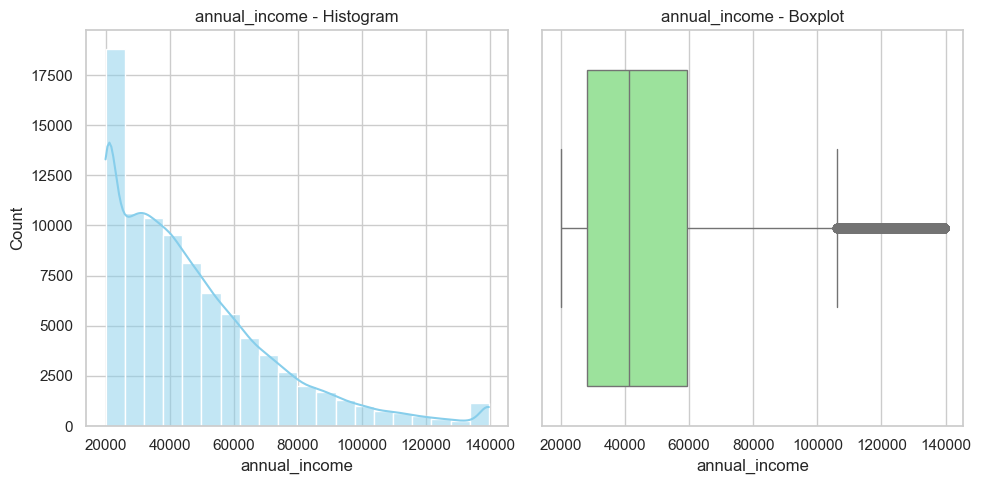

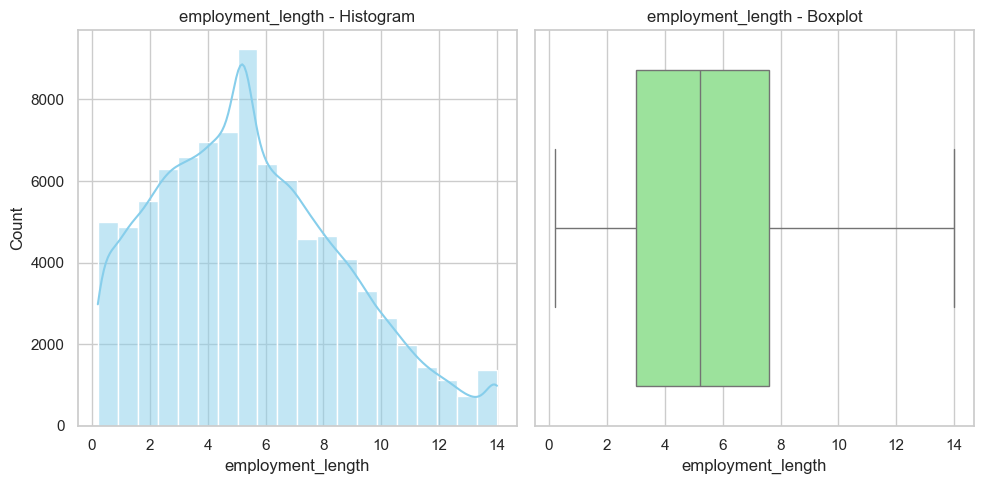

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\707935147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)


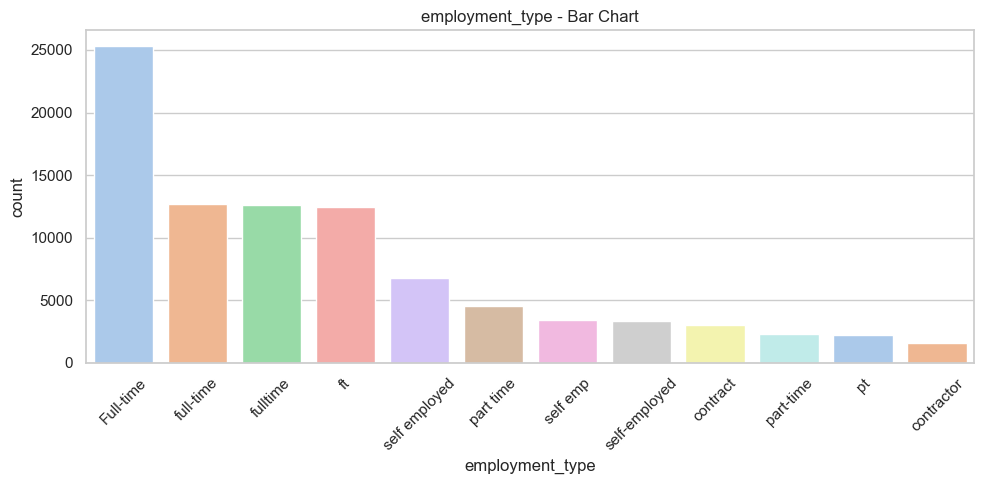

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\707935147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)


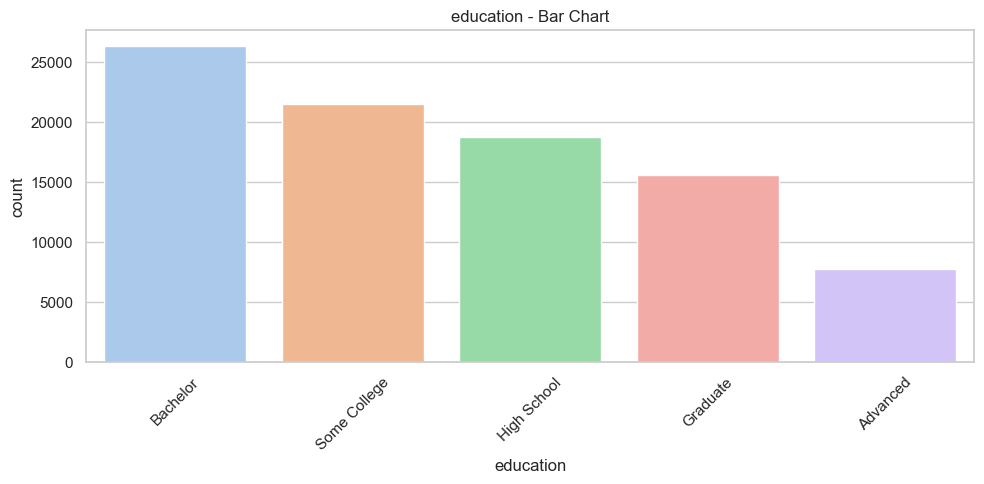

C:\Users\behru\AppData\Local\Temp\ipykernel_24496\707935147.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)


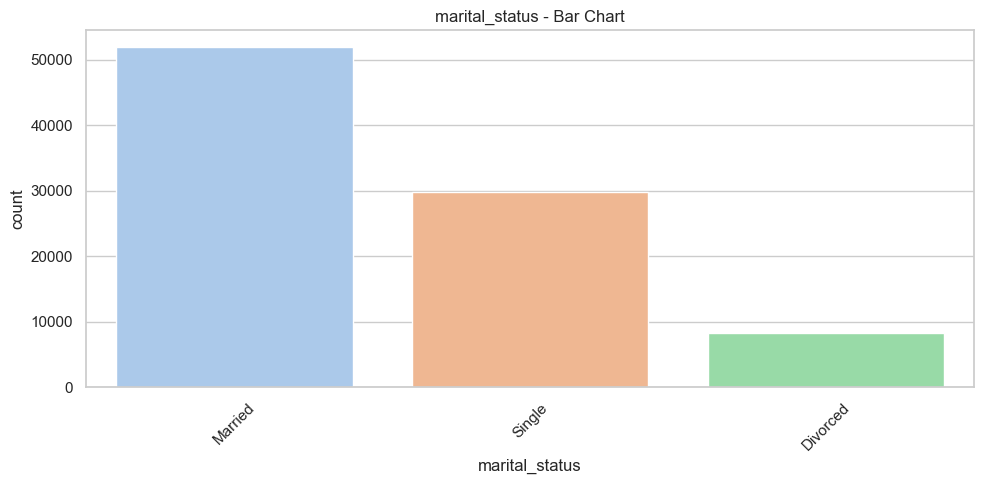

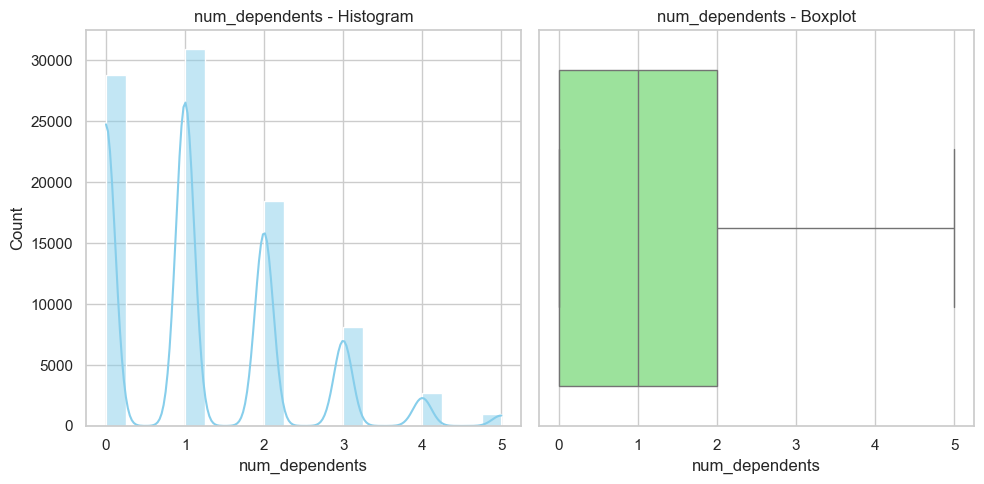

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ma'lumotlarni yuklash
data = pd.read_csv("demographics_clipped_except_age.csv")

# Vizualizatsiya sozlamalari
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# Har bir ustun bo'yicha grafik yaratish
for col in data.columns:
    plt.figure()
    
    if pd.api.types.is_numeric_dtype(data[col]):
        # Histogram
        plt.subplot(1,2,1)
        sns.histplot(data[col], kde=True, bins=20, color='skyblue')
        plt.title(f'{col} - Histogram')
        
        # Boxplot
        plt.subplot(1,2,2)
        sns.boxplot(x=data[col], color='lightgreen')
        plt.title(f'{col} - Boxplot')
        
    else:
        # Kategorik ustunlar uchun bar chart
        sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)
        plt.title(f'{col} - Bar Chart')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


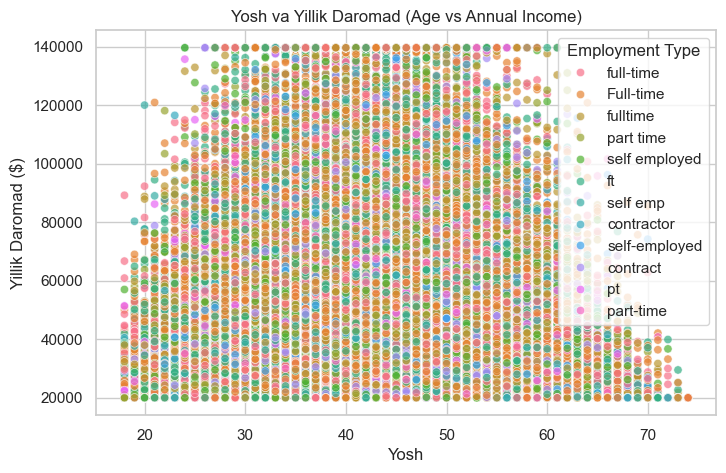

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ma'lumotlarni yuklash
data = pd.read_csv("demographics_clipped_except_age.csv")

# Scatter plot: Age vs Annual Income
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data,
    x='age',
    y='annual_income',
    hue='employment_type',   # Rang bo'yicha ajratish
    alpha=0.7
)
plt.title("Yosh va Yillik Daromad (Age vs Annual Income)")
plt.xlabel("Yosh")
plt.ylabel("Yillik Daromad ($)")
plt.legend(title="Employment Type")
plt.show()


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ma'lumotlarni yuklash
data = pd.read_csv("c.csv")

# Raqamli ustunlarni tanlash, 'age' ni chiqarib tashlamaymiz
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns if col != 'age']

# Har bir raqamli ustun bo'yicha scatter plot
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=data,
        x='age',
        y=col,
        hue='employment_type',
        alpha=0.7
    )
    plt.title(f"Yosh va {col} (Age vs {col})")
    plt.xlabel("Yosh")
    plt.ylabel(col)
    plt.legend(title="Employment Type")
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'c.csv'

In [ ]:
data['employment_type'].value_counts()

employment_type
Full-time        25300
full-time        12716
fulltime         12582
ft               12419
self employed     6736
part time         4494
self emp          3397
self-employed     3303
contract          2979
part-time         2266
pt                2247
contractor        1560
Name: count, dtype: int64

In [ ]:
data.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents
0,10899.98,41,61800,2.2,full-time,Graduate,Married,2
1,10899.98,38,28600,7.0,Full-time,High School,Married,0
2,10899.98,18,20700,0.8,Full-time,Bachelor,Single,0
3,10899.98,27,31400,4.8,Full-time,Bachelor,Single,0
4,10899.98,26,24600,5.2,fulltime,High School,Single,0


In [ ]:
import pandas as pd

# Ma'lumotlarni yuklash
data = pd.read_csv("demographics_clipped_except_age.csv")

# --- Funksiya: kategorik ustunlarni standartlashtirish ---
def standardize_categorical_columns(df):
    # 1. employment_type
    if 'employment_type' in df.columns:
        col = df['employment_type'].astype(str).str.lower().str.strip()
        mapping = {
            'full-time': ['full-time', 'fulltime', 'ft'],
            'part-time': ['part-time', 'part time', 'pt'],
            'self-employed': ['self-employed', 'self employed', 'self emp'],
            'contract': ['contract', 'contractor']
        }
        for standard, variants in mapping.items():
            col = col.replace(variants, standard)
        df['employment_type'] = col

    # 2. education
    if 'education' in df.columns:
        col = df['education'].astype(str).str.lower().str.strip()
        mapping = {
            'high school': ['high school', 'highschool', 'hs'],
            'bachelor': ['bachelor', 'bachelors', 'bsc', 'ba'],
            'graduate': ['graduate', 'master', 'phd', 'pg']
        }
        for standard, variants in mapping.items():
            col = col.replace(variants, standard)
        df['education'] = col

    # 3. marital_status
    if 'marital_status' in df.columns:
        col = df['marital_status'].astype(str).str.lower().str.strip()
        mapping = {
            'married': ['married', 'marriedd', 'mar'],
            'single': ['single', 'unmarried', 'singl'],
            'divorced': ['divorced', 'divorce']
        }
        for standard, variants in mapping.items():
            col = col.replace(variants, standard)
        df['marital_status'] = col

    return df

# --- Kategorik ustunlarni standartlashtirish ---
data = standardize_categorical_columns(data)

# --- Tozalangan data CSV ga saqlash ---
output_file = "demographics_cleaned_standardized.csv"
data.to_csv(output_file, index=False)

print(f"Tozalangan va standartlashtirilgan data '{output_file}' nomi bilan saqlandi.")


Tozalangan va standartlashtirilgan data 'demographics_cleaned_standardized.csv' nomi bilan saqlandi.


In [ ]:
data = pd.read_csv("demographics_cleaned_standardized.csv")

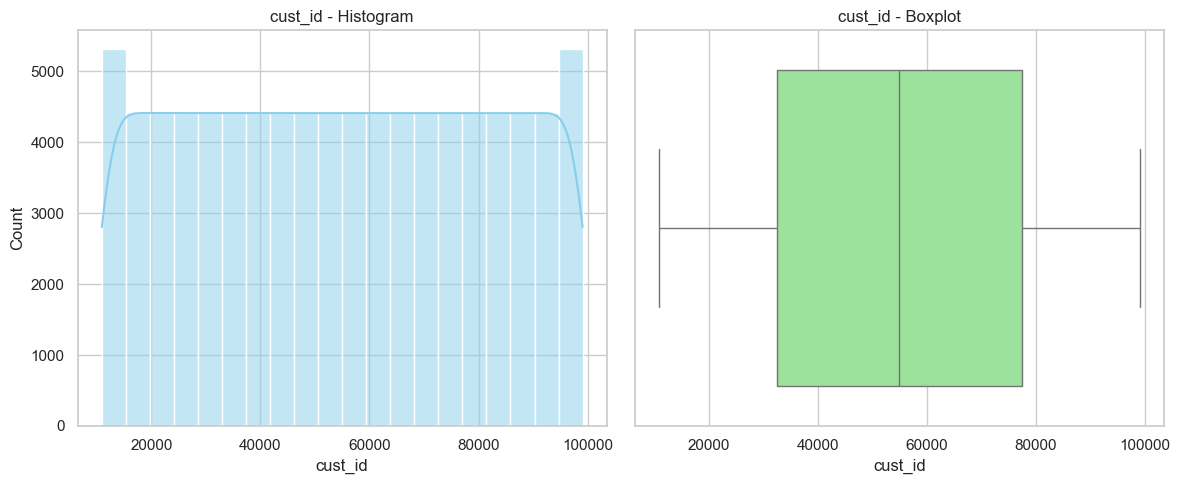

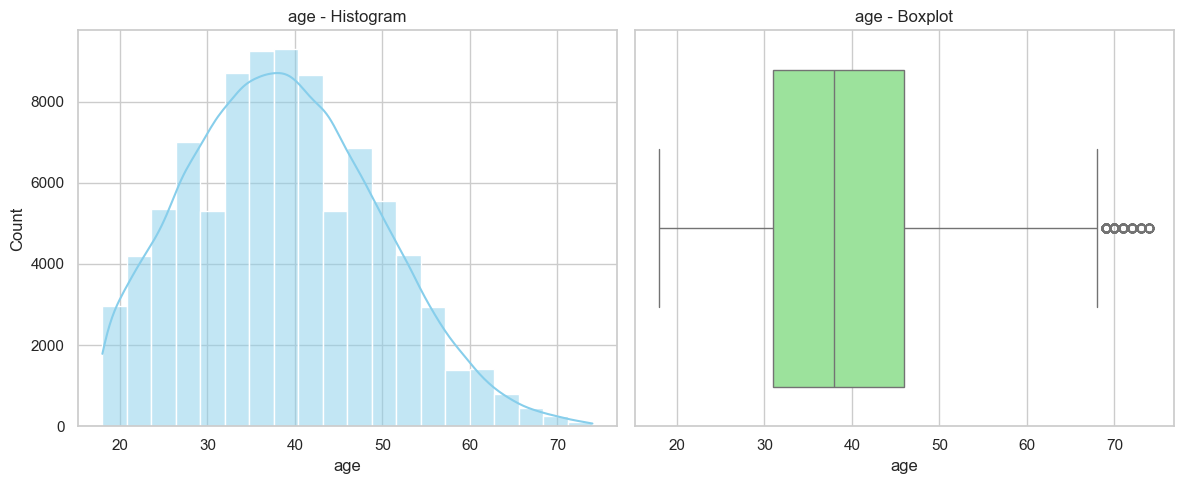

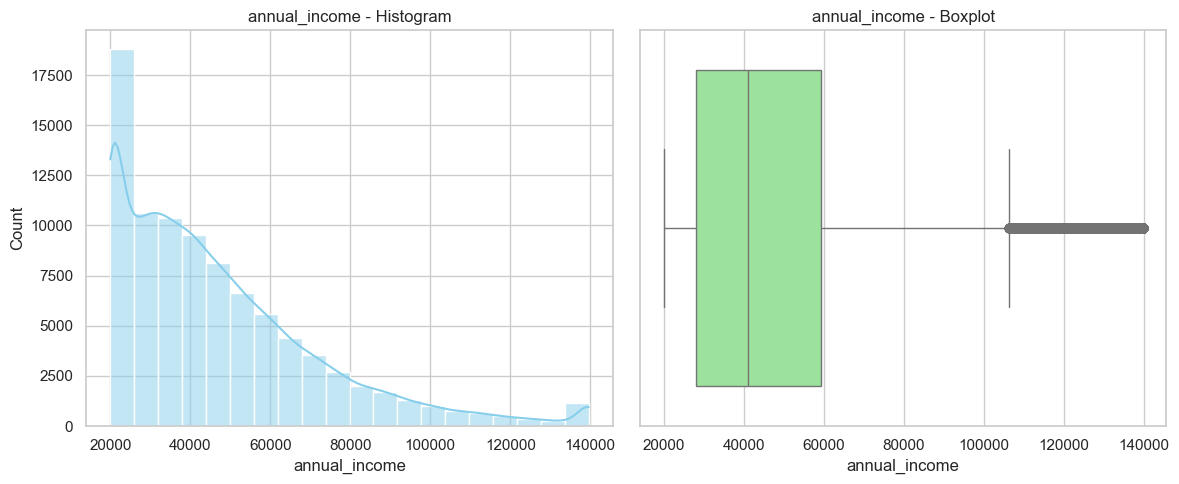

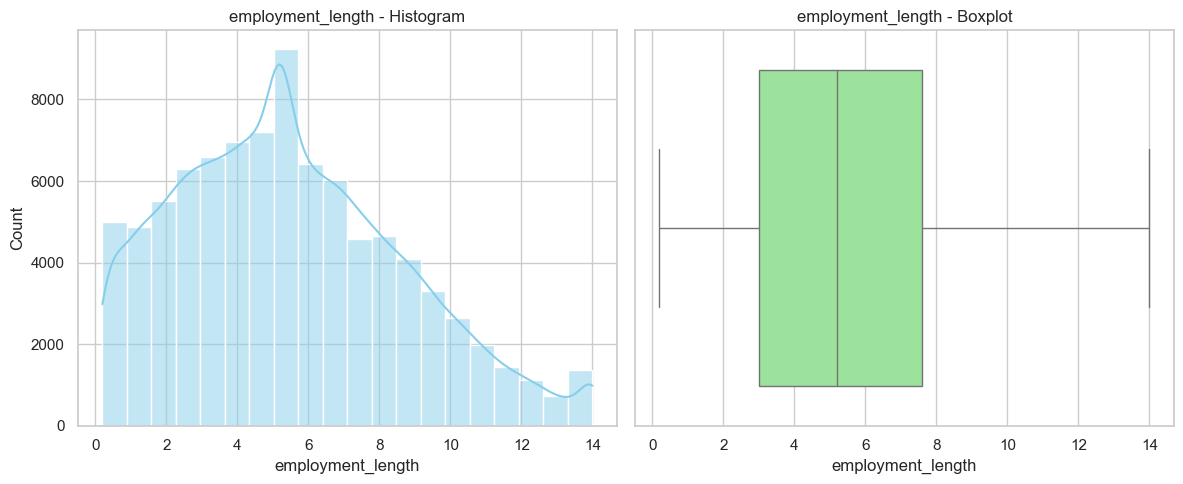

C:\Users\behru\AppData\Local\Temp\ipykernel_10024\379350965.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)


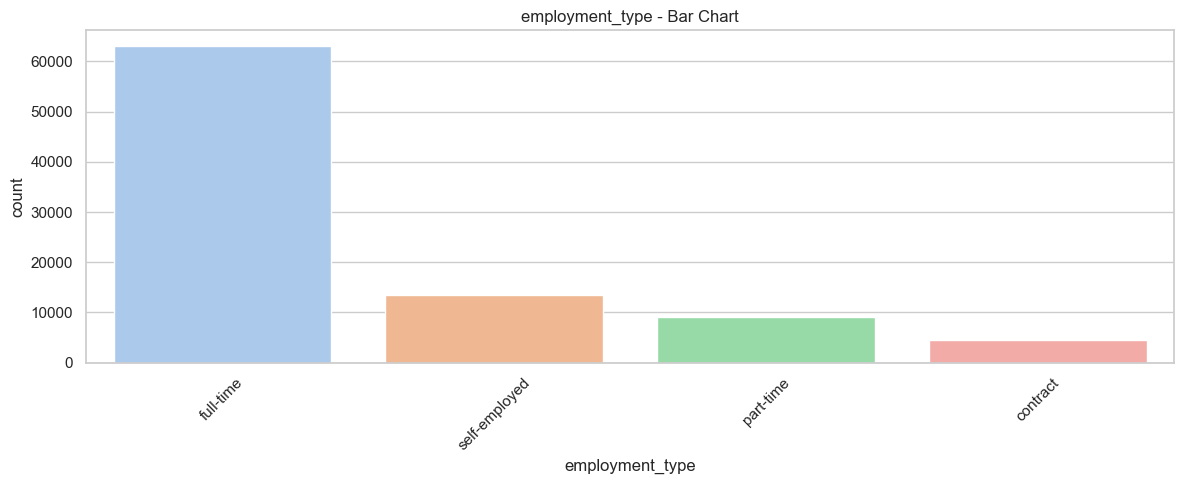

C:\Users\behru\AppData\Local\Temp\ipykernel_10024\379350965.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)


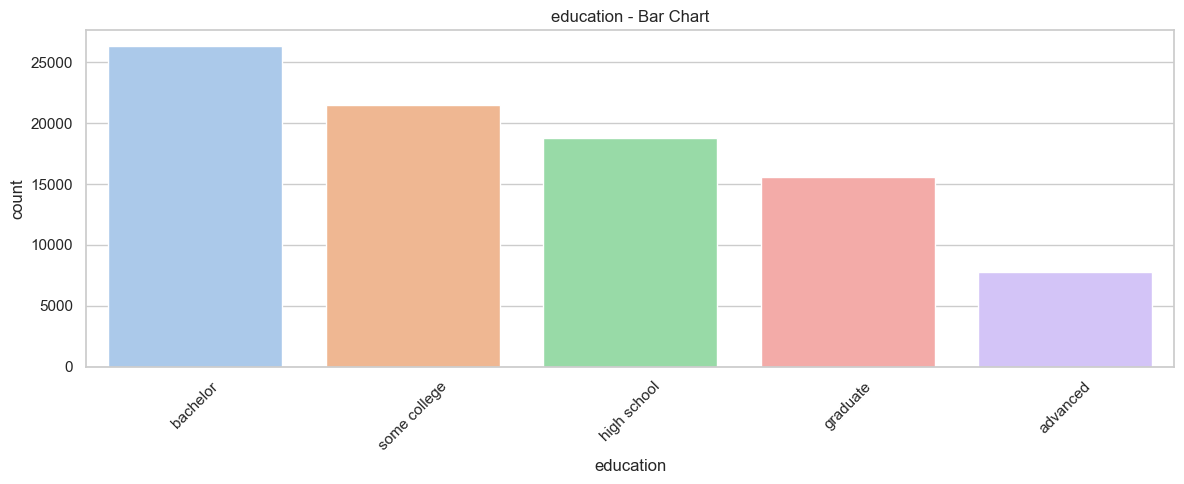

C:\Users\behru\AppData\Local\Temp\ipykernel_10024\379350965.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)


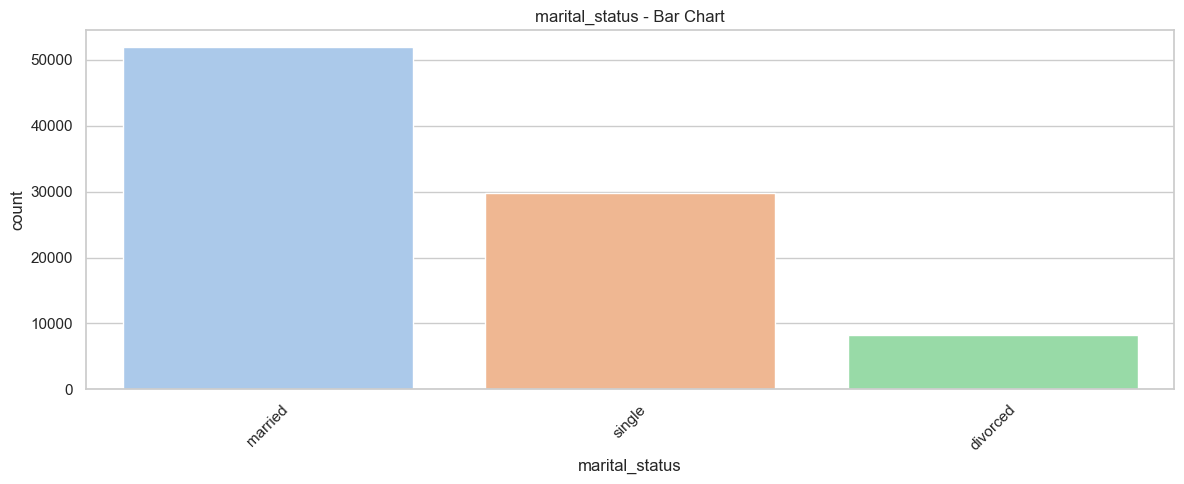

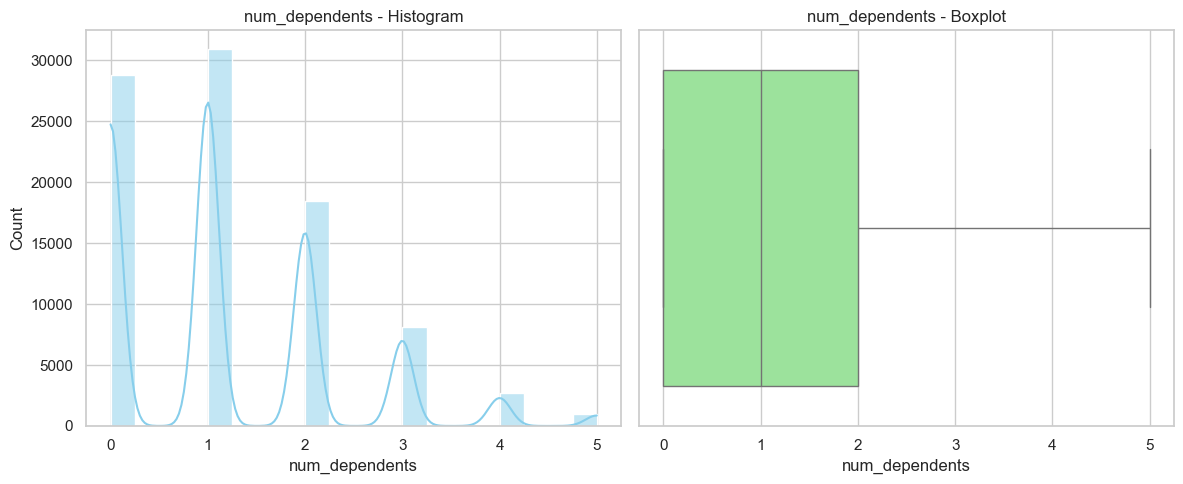

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ma'lumotlarni yuklash
data = pd.read_csv("demographics_cleaned_standardized.csv")

# Vizualizatsiya sozlamalari
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# Har bir ustun bo'yicha alohida grafik
for col in data.columns:
    plt.figure(figsize=(12,5))  # har bir figure uchun alohida o'lcham
    
    if pd.api.types.is_numeric_dtype(data[col]):
        # Raqamli ustun: Histogram + Boxplot
        plt.subplot(1,2,1)
        sns.histplot(data[col], kde=True, bins=20, color='skyblue')
        plt.title(f'{col} - Histogram')
        
        plt.subplot(1,2,2)
        sns.boxplot(x=data[col], color='lightgreen')
        plt.title(f'{col} - Boxplot')
        
    else:
        # Kategorik ustun: Bar chart
        sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)
        plt.title(f'{col} - Bar Chart')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


# bu asosiy

In [ ]:
\

FileNotFoundError: [Errno 2] No such file or directory: 'demographics_clipped_normalized_except_age.csv'

In [ ]:
data.employment_type.value_counts()

employment_type
full-time        63017
self-employed    13436
part-time         9007
contract          4539
Name: count, dtype: int64

In [ ]:
data.education.value_counts()

education
bachelor        26326
Some College    21543
high school     18794
graduate        15585
Advanced         7751
Name: count, dtype: int64

In [ ]:
data.marital_status.value_counts()

marital_status
married     51889
single      29806
divorced     8304
Name: count, dtype: int64

In [ ]:
data.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents
0,10000,41,0.349492,0.144928,full-time,graduate,married,0.4
1,10001,38,0.071905,0.492754,full-time,high school,married,0.0
2,10002,18,0.005853,0.043478,full-time,bachelor,single,0.0
3,10003,27,0.095316,0.333333,full-time,bachelor,single,0.0
4,10004,26,0.038461,0.362319,full-time,high school,single,0.0


Yosh (age) – demografik tahlil uchun kerak.

Annual_income – daromad bo‘yicha analiz va segmentatsiya.

Employment_length – ish tajribasi, daromad bilan bog‘liqlik.

Employment_type – ish turi kategoriyasi, analiz va modelda foydalanish.

Education – ta’lim darajasi, segmentatsiya va prediktsiya uchun.

Marital_status – oilaviy holat, ko‘pincha tahlil va modelda qo‘llanadi.

Num_dependents – oilaviy majburiyat, daromad va tahlilga ta’sir qiladi.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- 1. CSV faylni yuklash ---
data = pd.read_csv("demographics_final_clean_normalized_encoded.csv")

# --- 2. Mapping dictionarylar (kategoriyalarni tozalash uchun) ---
employment_map = {
    'full-time': ['full-time', 'fulltime', 'ft'],
    'part-time': ['part-time', 'part time', 'pt'],
    'self-employed': ['self-employed', 'self employed', 'self emp'],
    'contract': ['contract', 'contractor']
}

education_map = {
    'high school': ['high school', 'highschool', 'hs'],
    'bachelor': ['bachelor', 'bachelors', 'bsc', 'ba'],
    'graduate': ['graduate', 'master', 'phd', 'pg']
}

marital_map = {
    'married': ['married', 'marriedd', 'mar'],
    'single': ['single', 'unmarried', 'singl'],
    'divorced': ['divorced', 'divorce']
}

# --- 3. Kategoriyalarni tozalash funksiyasi ---
def normalize_category(value, mapping):
    if pd.isna(value):
        return value
    v = str(value).lower().strip()
    for standard, variants in mapping.items():
        if v in variants:
            return standard
    return value

# --- 4. Kategorik ustunlarni tozalash ---
data["employment_type"] = data["employment_type"].apply(lambda x: normalize_category(x, employment_map))
data["education"] = data["education"].apply(lambda x: normalize_category(x, education_map))
data["marital_status"] = data["marital_status"].apply(lambda x: normalize_category(x, marital_map))

# --- 5. Kategorik ustunlarni LabelEncoder orqali sonlarga aylantirish ---
categorical_cols = ["employment_type", "education", "marital_status"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col + "_encoded"] = le.fit_transform(data[col])
    label_encoders[col] = le  # keyinchalik inverse_transform uchun saqlash mumkin

# --- 6. Faqat categorik ustunlar va kodlangan ustunlarni CSV ga saqlash ---
output_file = "categorical_encoded.csv"
data[categorical_cols + [col + "_encoded" for col in categorical_cols]].to_csv(output_file, index=False)

print(f"Kategorik ustunlar va kodlangan versiyalari CSV ga saqlandi: {output_file}")
print(data[categorical_cols + [col + "_encoded" for col in categorical_cols]].head())


Kategorik ustunlar va kodlangan versiyalari CSV ga saqlandi: categorical_encoded.csv
  employment_type    education marital_status  employment_type_encoded  \
0       full-time     graduate        married                        1   
1       full-time  high school        married                        1   
2       full-time     bachelor         single                        1   
3       full-time     bachelor         single                        1   
4       full-time  high school         single                        1   

   education_encoded  marital_status_encoded  
0                  3                       1  
1                  4                       1  
2                  2                       2  
3                  2                       2  
4                  4                       2  


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- 1. CSV faylni yuklash ---
data = pd.read_csv("demographics_final_clean_normalized_encoded.csv")

# --- 2. Mapping dictionarylar (kategoriyalarni tozalash) ---
employment_map = {
    'full-time': ['full-time', 'fulltime', 'ft'],
    'part-time': ['part-time', 'part time', 'pt'],
    'self-employed': ['self-employed', 'self employed', 'self emp'],
    'contract': ['contract', 'contractor']
}

education_map = {
    'high school': ['high school', 'highschool', 'hs'],
    'bachelor': ['bachelor', 'bachelors', 'bsc', 'ba'],
    'graduate': ['graduate', 'master', 'phd', 'pg']
}

marital_map = {
    'married': ['married', 'marriedd', 'mar'],
    'single': ['single', 'unmarried', 'singl'],
    'divorced': ['divorced', 'divorce']
}

# --- 3. Kategoriyalarni tozalash funksiyasi ---
def normalize_category(value, mapping):
    if pd.isna(value):
        return value
    v = str(value).lower().strip()
    for standard, variants in mapping.items():
        if v in variants:
            return standard
    return value

# --- 4. Kategorik ustunlarni tozalash ---
data["employment_type"] = data["employment_type"].apply(lambda x: normalize_category(x, employment_map))
data["education"] = data["education"].apply(lambda x: normalize_category(x, education_map))
data["marital_status"] = data["marital_status"].apply(lambda x: normalize_category(x, marital_map))

# --- 5. Kategorik ustunlarni LabelEncoder orqali raqamlarga almashtirish ---
categorical_cols = ["employment_type", "education", "marital_status"]

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# --- 6. CSV ga saqlash (asl va boshqa ustunlar bilan birga) ---
output_file = "demographics_categorical_to_numeric.csv"
data.to_csv(output_file, index=False)

print(f"Kategorik ustunlar raqamlarga almashtirildi va CSV ga saqlandi: {output_file}")
print(data.head())


Kategorik ustunlar raqamlarga almashtirildi va CSV ga saqlandi: demographics_categorical_to_numeric.csv
   cust_id  age  annual_income  employment_length  employment_type  education  \
0    10000   41       0.349492           0.144928                1          3   
1    10001   38       0.071905           0.492754                1          4   
2    10002   18       0.005853           0.043478                1          2   
3    10003   27       0.095316           0.333333                1          2   
4    10004   26       0.038461           0.362319                1          4   

   marital_status  num_dependents  employment_type_num  education_num  \
0               1             0.4                  0.0            1.0   
1               1             0.0                  0.0            0.0   
2               2             0.0                  0.0            0.5   
3               2             0.0                  0.0            0.5   
4               2             0.0           

In [ ]:
data.employment_type_num.value_counts()

employment_type_num
0.000000    63017
0.666667    13436
0.333333     9007
1.000000     4539
Name: count, dtype: int64

In [ ]:
data1.head()

,cust_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents,employment_type_num,education_num,marital_status_num
0,10000,41,0.349492,0.144928,full-time,graduate,married,0.4,0.0,1.0,0.5
1,10001,38,0.071905,0.492754,full-time,high school,married,0.0,0.0,0.0,0.5
2,10002,18,0.005853,0.043478,full-time,bachelor,single,0.0,0.0,0.5,0.0
3,10003,27,0.095316,0.333333,full-time,bachelor,single,0.0,0.0,0.5,0.0
4,10004,26,0.038461,0.362319,full-time,high school,single,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd

# --- 1. CSV faylni yuklash ---
data = pd.read_csv("demographics_clipped_normalized_except_age_with_id.csv")

# --- 2. Kerakli ustunlar ro'yxati ---
required_cols = [
    'cust_id',  # ID ustunini saqlaymiz
    'age',
    'annual_income',
    'employment_length',
    'employment_type',
    'education',
    'marital_status',
    'num_dependents'
]

# --- 3. Qaysi ustunlar mavjudligini tekshirish ---
existing_cols = [col for col in required_cols if col in data.columns]
missing_cols = [col for col in required_cols if col not in data.columns]

print("Mavjud ustunlar:", existing_cols)
print("Yo'q ustunlar:", missing_cols)

# --- 4. Faqat mavjud kerakli ustunlarni tanlash ---
data_required = data[existing_cols]

# --- 5. Natijani CSV ga saqlash ---
output_file = "demographics_checked_required_columns.csv"
data_required.to_csv(output_file, index=False)

print(f"Kerakli ustunlar '{output_file}' nomi bilan saqlandi.")
print(data_required.head())


Mavjud ustunlar: ['cust_id', 'age', 'annual_income', 'employment_length', 'employment_type', 'education', 'marital_status', 'num_dependents']
Yo'q ustunlar: []
Kerakli ustunlar 'demographics_checked_required_columns.csv' nomi bilan saqlandi.
   cust_id  age  annual_income  employment_length employment_type  \
0    10000   41       0.349492           0.144928       full-time   
1    10001   38       0.071905           0.492754       full-time   
2    10002   18       0.005853           0.043478       full-time   
3    10003   27       0.095316           0.333333       full-time   
4    10004   26       0.038461           0.362319       full-time   

     education marital_status  num_dependents  
0     graduate        married             0.4  
1  high school        married             0.0  
2     bachelor         single             0.0  
3     bachelor         single             0.0  
4  high school         single             0.0  


In [ ]:
data